In [1]:
import kagglehub

datasetPath = kagglehub.dataset_download("gabrielluizone/us-domestic-flights-delay-prediction-2013-2018")

/home/dawidk/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4.1 Wczytaj dane i podaj liczbę wszystkich rekordów

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

csv_path = os.path.join(datasetPath, "flight_delay_predict.csv")
df = pd.read_csv(csv_path)

print(f"Liczba wszystkich rekordów: {len(df)}")
df.head()


Liczba wszystkich rekordów: 1635590


,is_delay,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,DestState,CRSDepTime,Cancelled,Diverted,Distance,DistanceGroup,ArrDelay,ArrDelayMinutes,AirTime
0,1.0,2014,1,1,1,3,2014-01-01,UA,LAX,CA,ORD,IL,900,0.0,0.0,1744.0,7,43.0,43.0,218.0
1,0.0,2014,1,1,1,3,2014-01-01,AA,IAH,TX,DFW,TX,1750,0.0,0.0,224.0,1,2.0,2.0,50.0
2,1.0,2014,1,1,1,3,2014-01-01,AA,LAX,CA,ORD,IL,1240,0.0,0.0,1744.0,7,26.0,26.0,220.0
3,1.0,2014,1,1,1,3,2014-01-01,AA,DFW,TX,LAX,CA,1905,0.0,0.0,1235.0,5,159.0,159.0,169.0
4,0.0,2014,1,1,1,3,2014-01-01,AA,DFW,TX,CLT,NC,1115,0.0,0.0,936.0,4,-13.0,0.0,108.0


## 4.2 Analiza linii lotniczych

### (a) Średnie opóźnienie dla każdej linii lotniczej

In [3]:
avg_delay = df.groupby("Reporting_Airline")["ArrDelay"].mean().sort_values(ascending=False)
avg_delay_df = avg_delay.reset_index()
avg_delay_df.columns = ["Linia lotnicza", "Średnie opóźnienie [min]"]
avg_delay_df["Średnie opóźnienie [min]"] = avg_delay_df["Średnie opóźnienie [min]"].round(2)
print(avg_delay_df.to_string(index=False))


Linia lotnicza  Średnie opóźnienie [min]
            OO                     10.77
            WN                     10.11
            AA                      5.89
            UA                      5.79
            DL                      2.24


### (b) Procent opóźnionych lotów dla każdej linii lotniczej

In [4]:
delay_pct = df.groupby("Reporting_Airline")["is_delay"].mean() * 100
delay_pct_df = delay_pct.sort_values(ascending=False).reset_index()
delay_pct_df.columns = ["Linia lotnicza", "Procent opóźnionych lotów [%]"]
delay_pct_df["Procent opóźnionych lotów [%]"] = delay_pct_df["Procent opóźnionych lotów [%]"].round(2)
print(delay_pct_df.to_string(index=False))


Linia lotnicza  Procent opóźnionych lotów [%]
            WN                          27.20
            OO                          25.07
            UA                          20.83
            AA                          20.62
            DL                          16.47


### (c) Ranking linii lotniczych

Ranking linii lotniczych (1. miejsce = najmniejsze średnie opóźnienie):
 Miejsce Linia lotnicza  Średnie opóźnienie [min]
       1             DL                      2.24
       2             UA                      5.79
       3             AA                      5.89
       4             WN                     10.11
       5             OO                     10.77


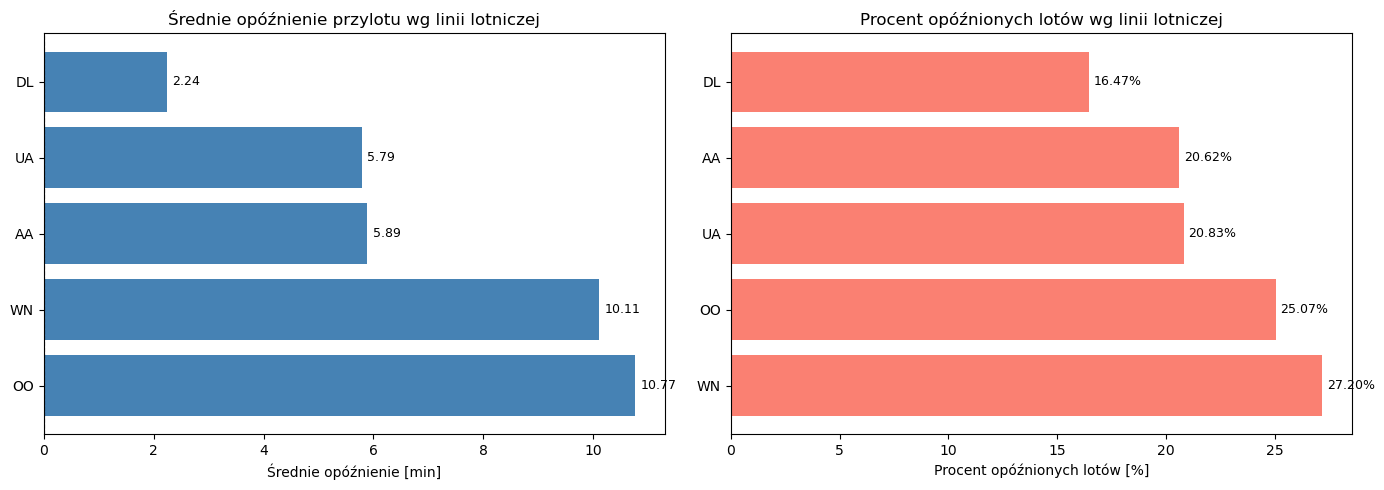

In [ ]:
# Ranking oparty na średnim opóźnieniu przylotu (rosnąco = lepsza linia)
ranking = avg_delay_df.copy().sort_values("Średnie opóźnienie [min]")
ranking.insert(0, "Miejsce", range(1, len(ranking) + 1))
print("Ranking linii lotniczych (1. miejsce = najmniejsze średnie opóźnienie):")
print(ranking.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Średnie opóźnienie
colors_avg = ["green" if v <= 0 else "steelblue" for v in avg_delay_df["Średnie opóźnienie [min]"]]
axes[0].barh(avg_delay_df["Linia lotnicza"], avg_delay_df["Średnie opóźnienie [min]"], color=colors_avg)
axes[0].set_xlabel("Średnie opóźnienie [min]")
axes[0].set_title("Średnie opóźnienie przylotu wg linii lotniczej")
axes[0].axvline(0, color="black", linewidth=0.8, linestyle="--")
for i, (airline, val) in enumerate(zip(avg_delay_df["Linia lotnicza"], avg_delay_df["Średnie opóźnienie [min]"])):
    axes[0].text(val + 0.1 if val >= 0 else val - 0.1, i, f"{val:.2f}", va="center",
                 ha="left" if val >= 0 else "right", fontsize=9)

# Wykres 2: Procent opóźnionych lotów
axes[1].barh(delay_pct_df["Linia lotnicza"], delay_pct_df["Procent opóźnionych lotów [%]"], color="salmon")
axes[1].set_xlabel("Procent opóźnionych lotów [%]")
axes[1].set_title("Procent opóźnionych lotów wg linii lotniczej")
for i, (airline, val) in enumerate(zip(delay_pct_df["Linia lotnicza"], delay_pct_df["Procent opóźnionych lotów [%]"])):
    axes[1].text(val + 0.2, i, f"{val:.2f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()


## 4.3 Analiza lotnisk

### (a) & (b) Lotniska generujące największe opóźnienia – średnie opóźnienie dla lotnisk wylotu

In [6]:
# Średnie opóźnienie przylotu dla każdego lotniska wylotu
airport_avg_delay = (
    df.groupby("Origin")["ArrDelay"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
airport_avg_delay.columns = ["Lotnisko wylotu", "Średnie opóźnienie [min]"]
airport_avg_delay["Średnie opóźnienie [min]"] = airport_avg_delay["Średnie opóźnienie [min]"].round(2)

print(f"Liczba unikalnych lotnisk wylotu: {len(airport_avg_delay)}\n")
print("Wszystkie lotniska – średnie opóźnienie (posortowane malejąco):")
print(airport_avg_delay.to_string(index=False))


Liczba unikalnych lotnisk wylotu: 9

Wszystkie lotniska – średnie opóźnienie (posortowane malejąco):
Lotnisko wylotu  Średnie opóźnienie [min]
            ORD                      8.41
            DFW                      7.67
            SFO                      7.44
            DEN                      6.23
            IAH                      6.17
            LAX                      5.77
            PHX                      4.56
            CLT                      3.68
            ATL                      2.55


### (c) 10 najgorszych lotnisk pod względem opóźnień

10 najgorszych lotnisk wylotu (największe średnie opóźnienie):
 Miejsce Lotnisko wylotu  Średnie opóźnienie [min]
       1             ORD                      8.41
       2             DFW                      7.67
       3             SFO                      7.44
       4             DEN                      6.23
       5             IAH                      6.17
       6             LAX                      5.77
       7             PHX                      4.56
       8             CLT                      3.68
       9             ATL                      2.55


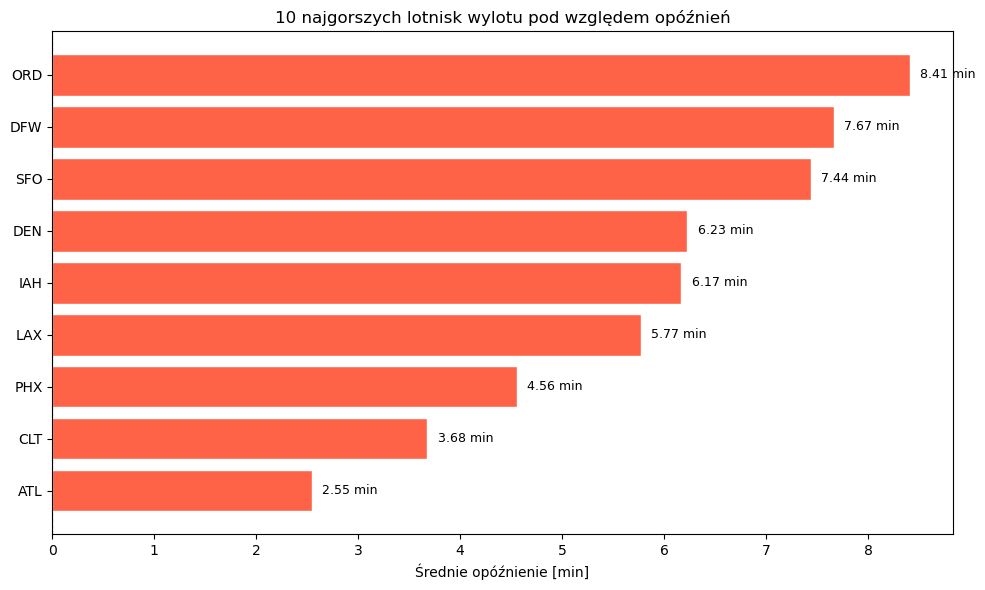

In [7]:
top10_worst = airport_avg_delay.head(10).copy()
top10_worst.insert(0, "Miejsce", range(1, len(top10_worst) + 1))

print("10 najgorszych lotnisk wylotu (największe średnie opóźnienie):")
print(top10_worst.to_string(index=False))

# Wykres słupkowy
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    top10_worst["Lotnisko wylotu"][::-1],
    top10_worst["Średnie opóźnienie [min]"][::-1],
    color="tomato",
    edgecolor="white"
)
ax.set_xlabel("Średnie opóźnienie [min]")
ax.set_title("10 najgorszych lotnisk wylotu pod względem opóźnień")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

for bar, val in zip(bars, top10_worst["Średnie opóźnienie [min]"][::-1]):
    ax.text(
        bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
        f"{val:.2f} min", va="center", fontsize=9
    )

plt.tight_layout()
plt.show()


## 4.4 Analiza sezonowości

### (a) Porównanie opóźnień w różnych miesiącach  
### (b) Identyfikacja okresów z największymi opóźnieniami

Średnie opóźnienie i procent opóźnionych lotów wg miesiąca:
Miesiąc  Śr. opóźnienie [min]  % opóźnionych
    Sty                  5.10          20.80
    Lut                  4.11          19.81
    Mar                  4.90          19.97
    Kwi                  4.47          19.08
    Maj                  7.39          22.41
    Cze                 11.53          26.47
    Lip                  9.57          24.71
    Sie                  9.41          24.52
    Wrz                  1.99          16.25
    Paź                  3.52          18.03
    Lis                  2.01          16.96
    Gru                  7.31          22.17

Najgorszy miesiąc: Cze (śr. opóźnienie 11.53 min, 26.47% lotów opóźnionych)
Najlepszy miesiąc: Wrz (śr. opóźnienie 1.99 min, 16.25% lotów opóźnionych)


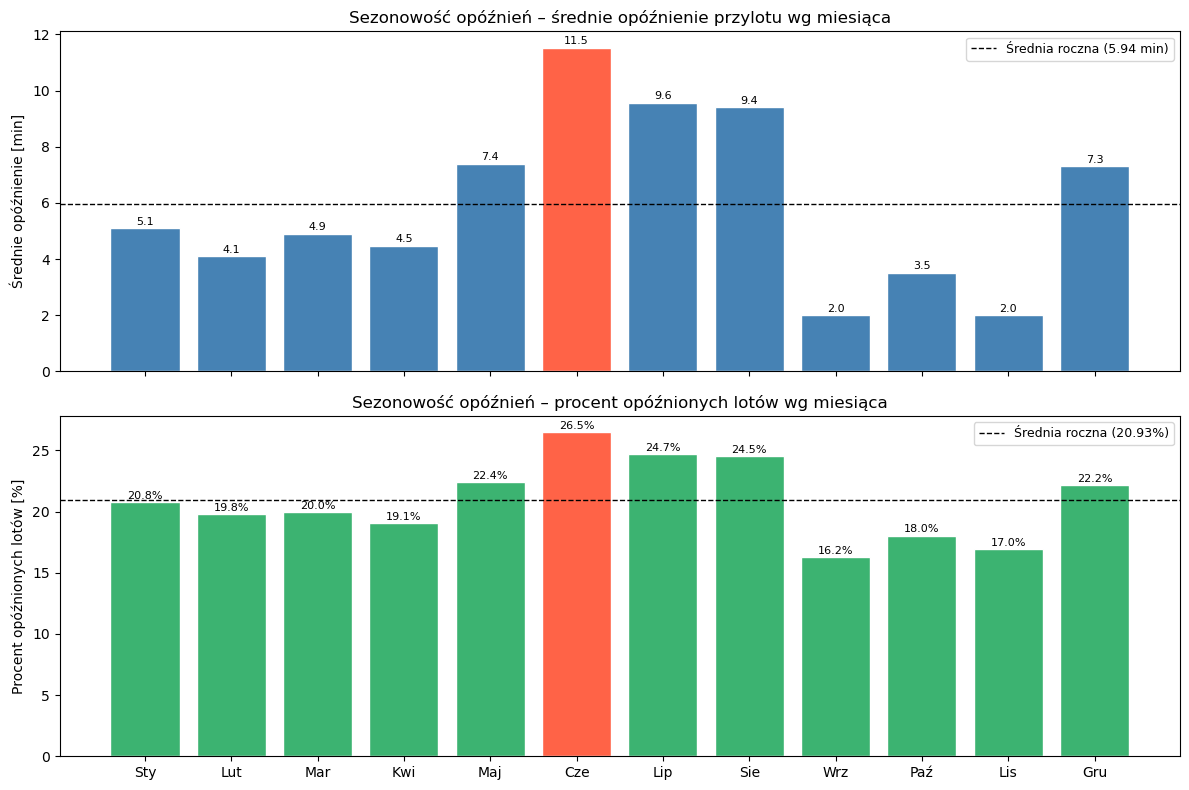

In [8]:
MONTH_NAMES = {
    1: "Sty", 2: "Lut", 3: "Mar", 4: "Kwi",
    5: "Maj", 6: "Cze", 7: "Lip", 8: "Sie",
    9: "Wrz", 10: "Paź", 11: "Lis", 12: "Gru"
}

# Średnie opóźnienie i procent opóźnionych lotów wg miesiąca
monthly = df.groupby("Month").agg(
    avg_delay=("ArrDelay", "mean"),
    pct_delayed=("is_delay", "mean")
).reset_index()
monthly["avg_delay"] = monthly["avg_delay"].round(2)
monthly["pct_delayed"] = (monthly["pct_delayed"] * 100).round(2)
monthly["Miesiąc"] = monthly["Month"].map(MONTH_NAMES)

print("Średnie opóźnienie i procent opóźnionych lotów wg miesiąca:")
print(monthly[["Miesiąc", "avg_delay", "pct_delayed"]].rename(
    columns={"avg_delay": "Śr. opóźnienie [min]", "pct_delayed": "% opóźnionych"}
).to_string(index=False))

# (b) – identyfikacja najgorszych okresów
worst_month = monthly.loc[monthly["avg_delay"].idxmax()]
best_month  = monthly.loc[monthly["avg_delay"].idxmin()]
print(f"\nNajgorszy miesiąc: {worst_month['Miesiąc']} "
      f"(śr. opóźnienie {worst_month['avg_delay']} min, "
      f"{worst_month['pct_delayed']}% lotów opóźnionych)")
print(f"Najlepszy miesiąc: {best_month['Miesiąc']} "
      f"(śr. opóźnienie {best_month['avg_delay']} min, "
      f"{best_month['pct_delayed']}% lotów opóźnionych)")

# Wykres
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Górny panel – średnie opóźnienie
bar_colors = ["tomato" if v == monthly["avg_delay"].max()
              else "steelblue" for v in monthly["avg_delay"]]
axes[0].bar(monthly["Miesiąc"], monthly["avg_delay"], color=bar_colors, edgecolor="white")
axes[0].set_ylabel("Średnie opóźnienie [min]")
axes[0].set_title("Sezonowość opóźnień – średnie opóźnienie przylotu wg miesiąca")
axes[0].axhline(monthly["avg_delay"].mean(), color="black", linewidth=1,
                linestyle="--", label=f"Średnia roczna ({monthly['avg_delay'].mean():.2f} min)")
axes[0].legend(fontsize=9)
for i, (x, v) in enumerate(zip(monthly["Miesiąc"], monthly["avg_delay"])):
    axes[0].text(i, v + 0.05, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

# Dolny panel – procent opóźnionych
bar_colors2 = ["tomato" if v == monthly["pct_delayed"].max()
               else "mediumseagreen" for v in monthly["pct_delayed"]]
axes[1].bar(monthly["Miesiąc"], monthly["pct_delayed"], color=bar_colors2, edgecolor="white")
axes[1].set_ylabel("Procent opóźnionych lotów [%]")
axes[1].set_title("Sezonowość opóźnień – procent opóźnionych lotów wg miesiąca")
axes[1].axhline(monthly["pct_delayed"].mean(), color="black", linewidth=1,
                linestyle="--", label=f"Średnia roczna ({monthly['pct_delayed'].mean():.2f}%)")
axes[1].legend(fontsize=9)
for i, (x, v) in enumerate(zip(monthly["Miesiąc"], monthly["pct_delayed"])):
    axes[1].text(i, v + 0.1, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()


## 4.5 Analiza odległości

### (a) Zależność między odległością lotu a opóźnieniem  
### (b) Wizualizacja zależności

Średnie opóźnienie i % opóźnionych wg grupy odległości:
 Grupa Zakres [mil]  Liczba lotów  Śr. opóźnienie [min]  % opóźnionych
     1      224–226         93468                  4.02          16.88
     2      337–370        183001                 10.82          27.00
     3      599–731        341728                  5.90          19.74
     4      802–967        397266                  6.91          21.65
     5    1009–1235        131283                  3.09          17.68
     6    1337–1464        145178                  5.37          20.48
     7    1587–1745        137826                  4.21          20.35
     8    1773–1947        145250                  5.83          22.05
     9    2125–2139         47157                  1.16          18.59
    10    2296–2296         13433                  3.87          21.48

Współczynnik korelacji Pearsona (Distance vs ArrDelay): -0.0272


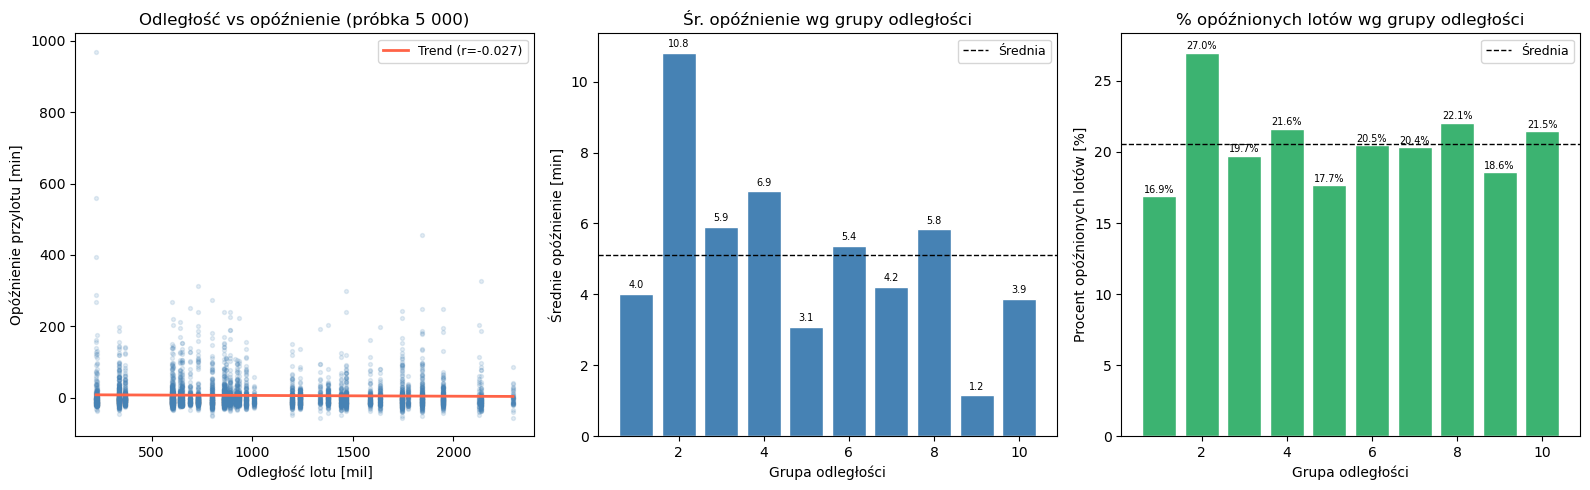

In [9]:
import numpy as np

# Usuń wiersze z brakującymi wartościami w kluczowych kolumnach
dist_df = df[["Distance", "DistanceGroup", "ArrDelay", "is_delay"]].dropna()

# --- Agregacja wg grup odległości (DistanceGroup 1–11, każda ~500 mil) ---
group_stats = dist_df.groupby("DistanceGroup").agg(
    count=("ArrDelay", "count"),
    avg_delay=("ArrDelay", "mean"),
    pct_delayed=("is_delay", "mean"),
    dist_min=("Distance", "min"),
    dist_max=("Distance", "max"),
).reset_index()
group_stats["avg_delay"]    = group_stats["avg_delay"].round(2)
group_stats["pct_delayed"]  = (group_stats["pct_delayed"] * 100).round(2)
group_stats["Zakres [mil]"] = group_stats["dist_min"].astype(int).astype(str) + "–" + group_stats["dist_max"].astype(int).astype(str)

print("Średnie opóźnienie i % opóźnionych wg grupy odległości:")
print(group_stats[["DistanceGroup", "Zakres [mil]", "count", "avg_delay", "pct_delayed"]]
      .rename(columns={"DistanceGroup": "Grupa", "count": "Liczba lotów",
                        "avg_delay": "Śr. opóźnienie [min]", "pct_delayed": "% opóźnionych"})
      .to_string(index=False))

# Współczynnik korelacji Pearsona
corr = dist_df["Distance"].corr(dist_df["ArrDelay"])
print(f"\nWspółczynnik korelacji Pearsona (Distance vs ArrDelay): {corr:.4f}")

# --- Wykresy ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Wykres punktowy (próbka 5 000 rekordów dla czytelności)
sample = dist_df.sample(n=min(5000, len(dist_df)), random_state=42)
axes[0].scatter(sample["Distance"], sample["ArrDelay"], alpha=0.15, s=8, color="steelblue")

# Linia trendu
m, b = np.polyfit(dist_df["Distance"], dist_df["ArrDelay"], 1)
x_line = np.linspace(dist_df["Distance"].min(), dist_df["Distance"].max(), 200)
axes[0].plot(x_line, m * x_line + b, color="tomato", linewidth=2,
             label=f"Trend (r={corr:.3f})")
axes[0].set_xlabel("Odległość lotu [mil]")
axes[0].set_ylabel("Opóźnienie przylotu [min]")
axes[0].set_title("Odległość vs opóźnienie (próbka 5 000)")
axes[0].legend(fontsize=9)

# 2. Średnie opóźnienie wg grupy odległości
axes[1].bar(group_stats["DistanceGroup"], group_stats["avg_delay"],
            color="steelblue", edgecolor="white")
axes[1].axhline(group_stats["avg_delay"].mean(), color="black", linewidth=1,
                linestyle="--", label="Średnia")
axes[1].set_xlabel("Grupa odległości")
axes[1].set_ylabel("Średnie opóźnienie [min]")
axes[1].set_title("Śr. opóźnienie wg grupy odległości")
axes[1].legend(fontsize=9)
for _, row in group_stats.iterrows():
    axes[1].text(row["DistanceGroup"], row["avg_delay"] + 0.1,
                 f"{row['avg_delay']:.1f}", ha="center", va="bottom", fontsize=7)

# 3. Procent opóźnionych wg grupy odległości
axes[2].bar(group_stats["DistanceGroup"], group_stats["pct_delayed"],
            color="mediumseagreen", edgecolor="white")
axes[2].axhline(group_stats["pct_delayed"].mean(), color="black", linewidth=1,
                linestyle="--", label="Średnia")
axes[2].set_xlabel("Grupa odległości")
axes[2].set_ylabel("Procent opóźnionych lotów [%]")
axes[2].set_title("% opóźnionych lotów wg grupy odległości")
axes[2].legend(fontsize=9)
for _, row in group_stats.iterrows():
    axes[2].text(row["DistanceGroup"], row["pct_delayed"] + 0.1,
                 f"{row['pct_delayed']:.1f}%", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()


## 4.6 Analiza anulowanych i przekierowanych lotów

### (a) Procent anulowanych lotów wg linii lotniczej  
### (b) Procent przekierowanych lotów wg linii lotniczej

In [11]:
# --- (a) & (b) Procent anulowanych i przekierowanych wg linii lotniczej ---
print("Unikalne wartości kolumny 'Cancelled':", df["Cancelled"].unique())
print("Unikalne wartości kolumny 'Diverted':", df["Diverted"].unique())
print()
print("Plik flight_delay_predict.csv zawiera wyłącznie loty zrealizowane.")
print("Kolumny 'Cancelled' i 'Diverted' przyjmują jedynie wartość 0 dla wszystkich rekordów.")
print("Oznacza to, że procent anulowanych i przekierowanych lotów wynosi 0% dla każdej linii.")
print()
print("Wniosek: zbiór danych został wstępnie przefiltrowany — nie zawiera anulowań ani przekierowań.")
print("Analiza (a) i (b) nie jest możliwa na tym zbiorze — brak zmienności w tych kolumnach.")


Unikalne wartości kolumny 'Cancelled': [0.]
Unikalne wartości kolumny 'Diverted': [0.]

Plik flight_delay_predict.csv zawiera wyłącznie loty zrealizowane.
Kolumny 'Cancelled' i 'Diverted' przyjmują jedynie wartość 0 dla wszystkich rekordów.
Oznacza to, że procent anulowanych i przekierowanych lotów wynosi 0% dla każdej linii.

Wniosek: zbiór danych został wstępnie przefiltrowany — nie zawiera anulowań ani przekierowań.
Analiza (a) i (b) nie jest możliwa na tym zbiorze — brak zmienności w tych kolumnach.


### (c) Zależność opóźnień od czasu (miesiąc i dzień tygodnia)

Procent opóźnionych lotów wg dnia tygodnia:
Dzień  Śr. opóźnienie [min]  % opóźnionych
  Pon                  7.75          22.61
  Wto                  4.15          19.12
  Śro                  5.52          20.18
  Czw                  7.97          23.23
  Pią                  7.93          22.99
  Sob                  2.09          17.04
  Nie                  5.89          20.96

Najgorszy dzień tygodnia: Czw (23.23% opóźnionych, śr. 7.97 min)
Najlepszy dzień tygodnia: Sob  (17.04% opóźnionych, śr. 2.09 min)


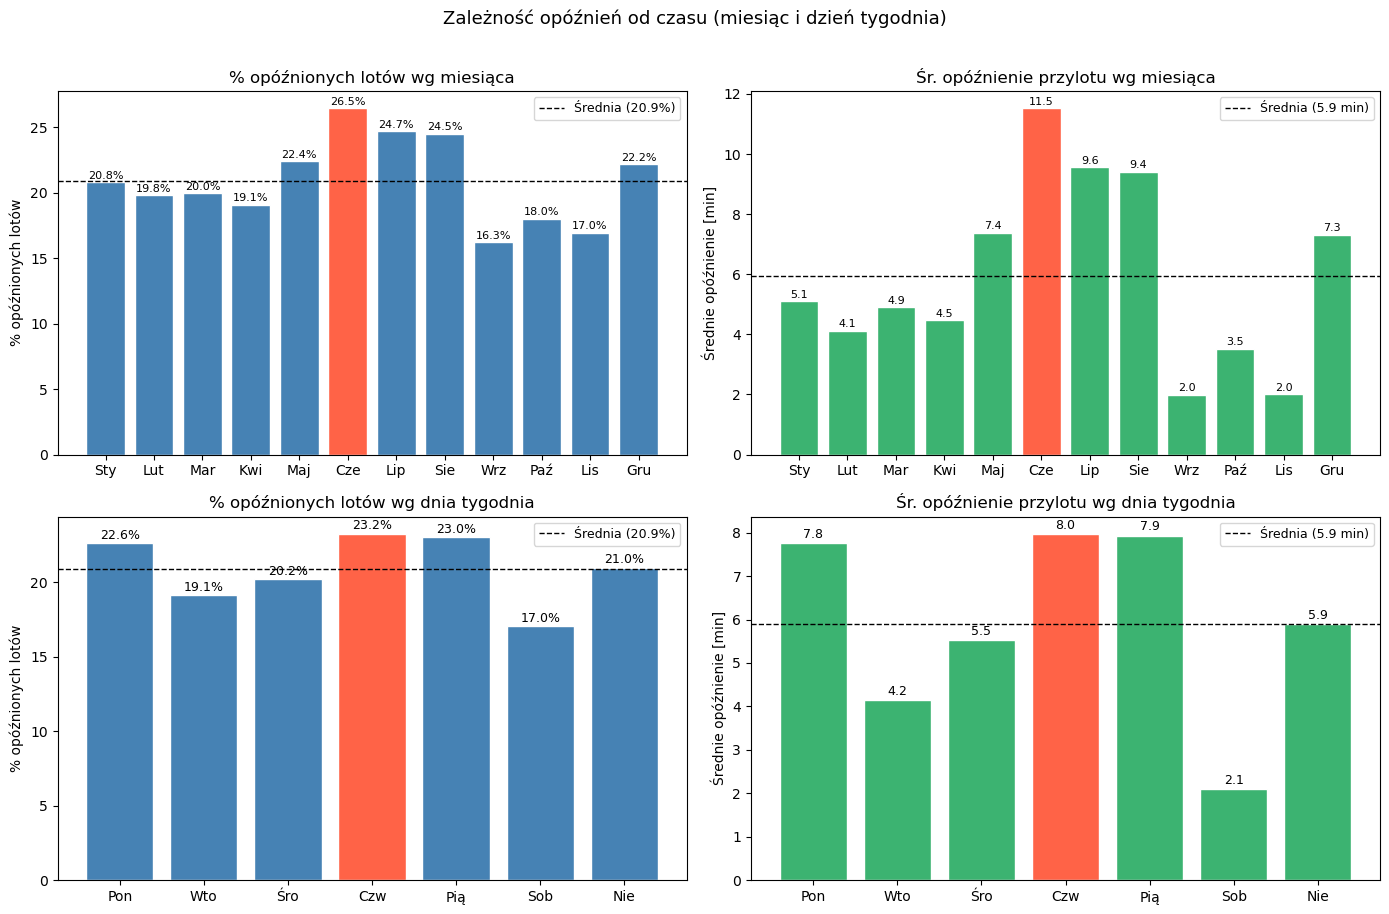

In [12]:
DAY_NAMES = {1: "Pon", 2: "Wto", 3: "Śro", 4: "Czw", 5: "Pią", 6: "Sob", 7: "Nie"}

# Zależność od miesiąca — już analizowana w 4.4, tutaj powtórzenie w kontekście 4.6
monthly_delay = df.groupby("Month")["is_delay"].mean() * 100

# Zależność od dnia tygodnia
dow_delay = df.groupby("DayOfWeek").agg(
    pct_delayed=("is_delay", "mean"),
    avg_delay=("ArrDelay", "mean"),
).reset_index()
dow_delay["pct_delayed"] = (dow_delay["pct_delayed"] * 100).round(2)
dow_delay["avg_delay"]   = dow_delay["avg_delay"].round(2)
dow_delay["Dzień"]       = dow_delay["DayOfWeek"].map(DAY_NAMES)

print("Procent opóźnionych lotów wg dnia tygodnia:")
print(dow_delay[["Dzień", "avg_delay", "pct_delayed"]]
      .rename(columns={"avg_delay": "Śr. opóźnienie [min]", "pct_delayed": "% opóźnionych"})
      .to_string(index=False))

worst_dow = dow_delay.loc[dow_delay["pct_delayed"].idxmax()]
best_dow  = dow_delay.loc[dow_delay["pct_delayed"].idxmin()]
print(f"\nNajgorszy dzień tygodnia: {worst_dow['Dzień']} ({worst_dow['pct_delayed']}% opóźnionych, śr. {worst_dow['avg_delay']} min)")
print(f"Najlepszy dzień tygodnia: {best_dow['Dzień']}  ({best_dow['pct_delayed']}% opóźnionych, śr. {best_dow['avg_delay']} min)")

# --- Wykresy ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (c1) % opóźnionych wg miesiąca
month_labels = [MONTH_NAMES[m] for m in sorted(df["Month"].unique())]
bar_c_month = ["tomato" if v == monthly_delay.max() else "steelblue" for v in monthly_delay]
axes[0, 0].bar(month_labels, monthly_delay.values, color=bar_c_month, edgecolor="white")
axes[0, 0].axhline(monthly_delay.mean(), color="black", linewidth=1, linestyle="--",
                   label=f"Średnia ({monthly_delay.mean():.1f}%)")
axes[0, 0].set_ylabel("% opóźnionych lotów")
axes[0, 0].set_title("% opóźnionych lotów wg miesiąca")
axes[0, 0].legend(fontsize=9)
for i, v in enumerate(monthly_delay.values):
    axes[0, 0].text(i, v + 0.1, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

# (c2) Śr. opóźnienie wg miesiąca
monthly_avg = df.groupby("Month")["ArrDelay"].mean()
bar_c_avg   = ["tomato" if v == monthly_avg.max() else "mediumseagreen" for v in monthly_avg]
axes[0, 1].bar(month_labels, monthly_avg.values, color=bar_c_avg, edgecolor="white")
axes[0, 1].axhline(monthly_avg.mean(), color="black", linewidth=1, linestyle="--",
                   label=f"Średnia ({monthly_avg.mean():.1f} min)")
axes[0, 1].set_ylabel("Średnie opóźnienie [min]")
axes[0, 1].set_title("Śr. opóźnienie przylotu wg miesiąca")
axes[0, 1].legend(fontsize=9)
for i, v in enumerate(monthly_avg.values):
    axes[0, 1].text(i, v + 0.05, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

# (c3) % opóźnionych wg dnia tygodnia
bar_c_dow = ["tomato" if v == dow_delay["pct_delayed"].max() else "steelblue"
             for v in dow_delay["pct_delayed"]]
axes[1, 0].bar(dow_delay["Dzień"], dow_delay["pct_delayed"], color=bar_c_dow, edgecolor="white")
axes[1, 0].axhline(dow_delay["pct_delayed"].mean(), color="black", linewidth=1, linestyle="--",
                   label=f"Średnia ({dow_delay['pct_delayed'].mean():.1f}%)")
axes[1, 0].set_ylabel("% opóźnionych lotów")
axes[1, 0].set_title("% opóźnionych lotów wg dnia tygodnia")
axes[1, 0].legend(fontsize=9)
for i, v in enumerate(dow_delay["pct_delayed"]):
    axes[1, 0].text(i, v + 0.1, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

# (c4) Śr. opóźnienie wg dnia tygodnia
bar_c_dow2 = ["tomato" if v == dow_delay["avg_delay"].max() else "mediumseagreen"
              for v in dow_delay["avg_delay"]]
axes[1, 1].bar(dow_delay["Dzień"], dow_delay["avg_delay"], color=bar_c_dow2, edgecolor="white")
axes[1, 1].axhline(dow_delay["avg_delay"].mean(), color="black", linewidth=1, linestyle="--",
                   label=f"Średnia ({dow_delay['avg_delay'].mean():.1f} min)")
axes[1, 1].set_ylabel("Średnie opóźnienie [min]")
axes[1, 1].set_title("Śr. opóźnienie przylotu wg dnia tygodnia")
axes[1, 1].legend(fontsize=9)
for i, v in enumerate(dow_delay["avg_delay"]):
    axes[1, 1].text(i, v + 0.05, f"{v:.1f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Zależność opóźnień od czasu (miesiąc i dzień tygodnia)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
